# 02 - Exploratory Data Analysis

This notebook explores the distribution of the dataset to identify patterns, detect potential outliers, and understand relationships between features and the diabetes outcome variable. This step helps guide modeling decisions and provides useful insights into which features may influence diabetes risk.

We begin by examining:

- The distribution of the target variable (`Outcome`)
- Summary statistics and feature distributions
- Potential relationships between features and diabetes status

Plotting logic lives in `src/visualization/plots.py` - this notebook calls those functions.

In [1]:
import sys, os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
# print("Working directory:", Path.cwd())

In [2]:
from src.data.load_data import load_config, load_data
from src.data.preprocess import clean_data
from src.visualization.plots import (
    plot_outcome_distribution,
    plot_feature_distributions,
    plot_correlation_heatmap,
    plot_boxplots_by_outcome,
)

## Load and clean data

In [3]:
config = load_config()
df = load_data(config)
invalid_cols = config["data"]["invalid_zero_columns"]
target_col = config["data"]["target_column"]
df_clean = clean_data(df, invalid_cols)
feature_cols = [c for c in df_clean.columns if c != target_col]
df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125.0,33.6,0.627,50,1
1,1,85,66,29,125.0,26.6,0.351,31,0
2,8,183,64,29.0,125.0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Outcome distribution

How balanced are the two classes? This matters for interpreting accuracy later - a skewed dataset makes a naive majority-class baseline harder to beat.

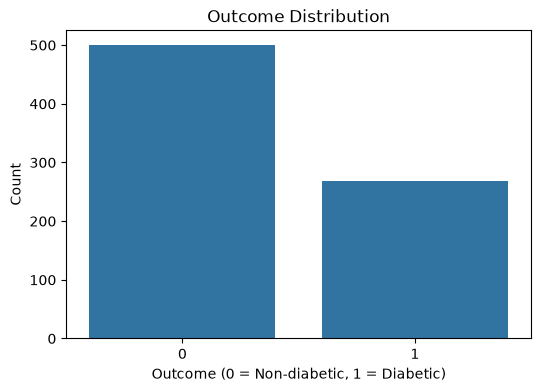

In [4]:
# Figures are saved to reports/figures/
fig = plot_outcome_distribution(df_clean, target_col, save_path="reports/figures/diabetes_outcome_distribution.png")

In [5]:
# Actual counts and percentages
counts = df['Outcome'].value_counts()
count_percentages = (counts / len(df)) * 100

print(f"\nActual Outcome Count: \n{counts}")
print(f"\nPercenatge Count: \n{count_percentages.round(0)}")


Actual Outcome Count: 
Outcome
0    500
1    268
Name: count, dtype: int64

Percenatge Count: 
Outcome
0    65.0
1    35.0
Name: count, dtype: float64


### Class Distribution Observation  

In this dataset, there is a fair degree of class imbalance, where roughly 65% of data instances have a classification of "Non-Diabetic" (Outcome = 0), while 35% of data instances have "Diabetic" (Outcome = 1).

Due to this class imbalance, accuracy alone cannot be used as an accurate performance metric for model evaluation. Other measures like precision, recall, F1 score, and ROC-AUC will be taken into consideration during evaluation.

## Feature distributions

Histograms of each feature, to check for skew and roughly where values cluster.

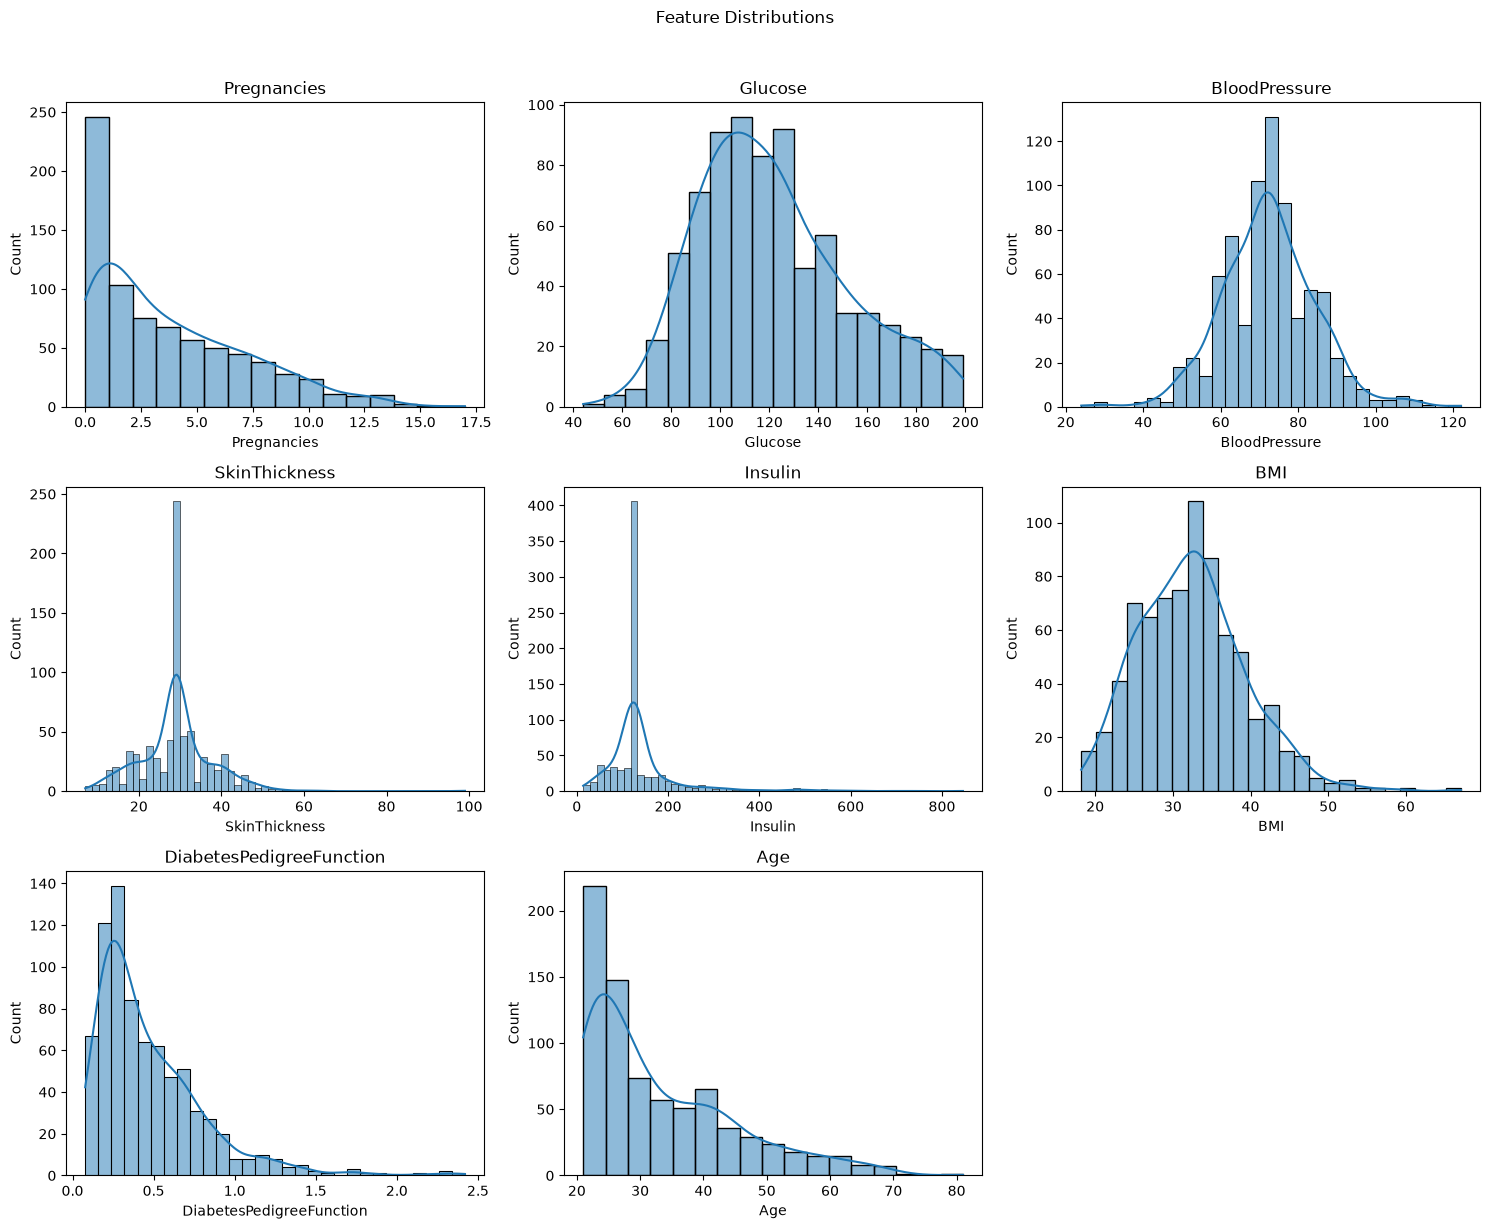

In [6]:
fig = plot_feature_distributions(df_clean, feature_cols, save_path="reports/figures/feature_distributions.png")

### Feature Distribution Analysis  

The distribution plots show how each feature is spread across the dataset:

- **Pregnancies:** Most participants had between 0–6 pregnancies, with a few women having a much higher number, causing a slight positive skew.
- **Glucose:** Generally right-skewed with most values clustering between 80–140 mg/dL, indicating that a minority have very high glucose levels.
- **BloodPressure:** Approximately symmetric, with most values around 60–80 mm Hg and few outliers.
- **SkinThickness:** Slightly right-skewed, with a long tail towards higher values, suggesting some extreme measurements.
- **Insulin:** Highly right-skewed and contains extreme values, indicating some participants have unusually high insulin measurements.
- **BMI:** Slightly positively skewed; most participants fall within the overweight to obese range.
- **DiabetesPedigreeFunction:** Right-skewed, with a few individuals having very high genetic risk scores.
- **Age:** Slight positive skew with most participants in their 20s–40s, and some older individuals.  

**Key Takeaways:**

- Features like `Insulin`, `SkinThickness`, and `DiabetesPedigreeFunction` are highly skewed, which could affect certain models and may benefit from transformations.
- Most other features have distributions that can be used directly in modeling.
- Understanding these distributions is essential to choose proper preprocessing, model selection, and interpretation strategies.

## Correlation heatmap

Which features move together, and which correlate most strongly with the outcome?

To better understand which features are predictive of diabetes and how features relate to each other, we examine:

**Correlation Heatmap:** Measures the linear relationships between all numerical variables, including the target variable `Outcome`.

- Features highly correlated with `Outcome` may have more predictive power.
- Highly correlated features with each other may introduce redundancy in certain models.

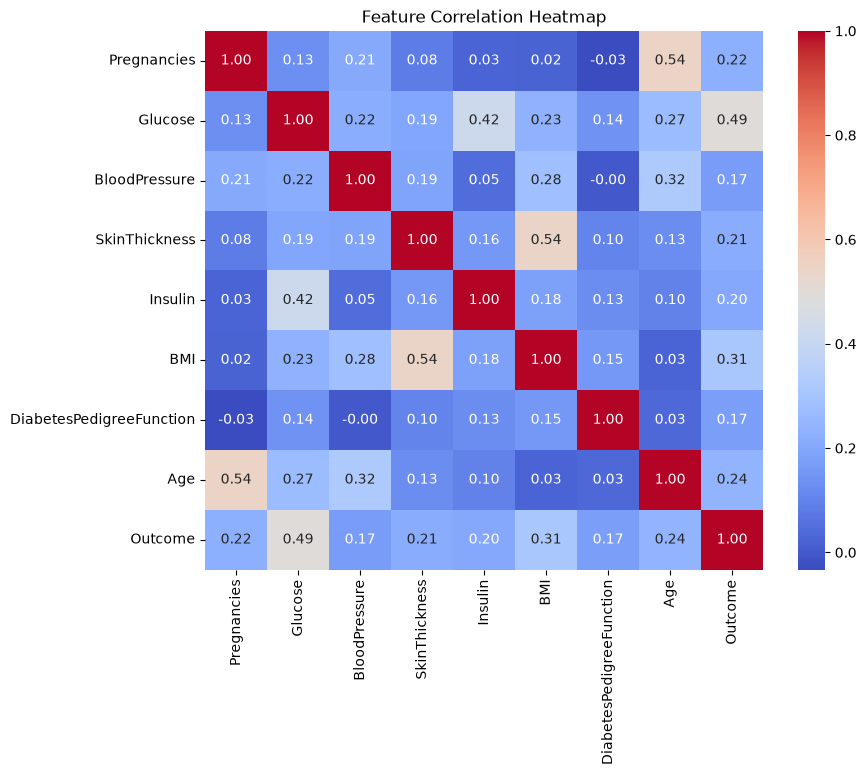

In [7]:
fig = plot_correlation_heatmap(df_clean, save_path="reports/figures/feature_correlation_heatmap.png")

### Feature Relationships with Diabetes Outcome  

#### Correlation Analysis
The Pearson correlation coefficients between each feature and the target variable `Outcome` show which features are most strongly associated with diabetes:

- **Glucose** has the highest positive correlation with Outcome (≈ 0.49), indicating that higher glucose levels are strongly associated with diabetes.
- **BMI** (≈ 0.31) and **Age** (≈ 0.24) also show moderate positive correlations.
- Other features such as **Pregnancies**, **SkinThickness**, **Insulin**, **DiabetesPedigreeFunction**, and **BloodPressure** show weaker positive correlations (≈ 0.16–0.22).

## Feature distributions by outcome

Boxplots comparing each feature's spread between diabetic and non-diabetic patients - a visual preview of which features are likely to matter most for classification.

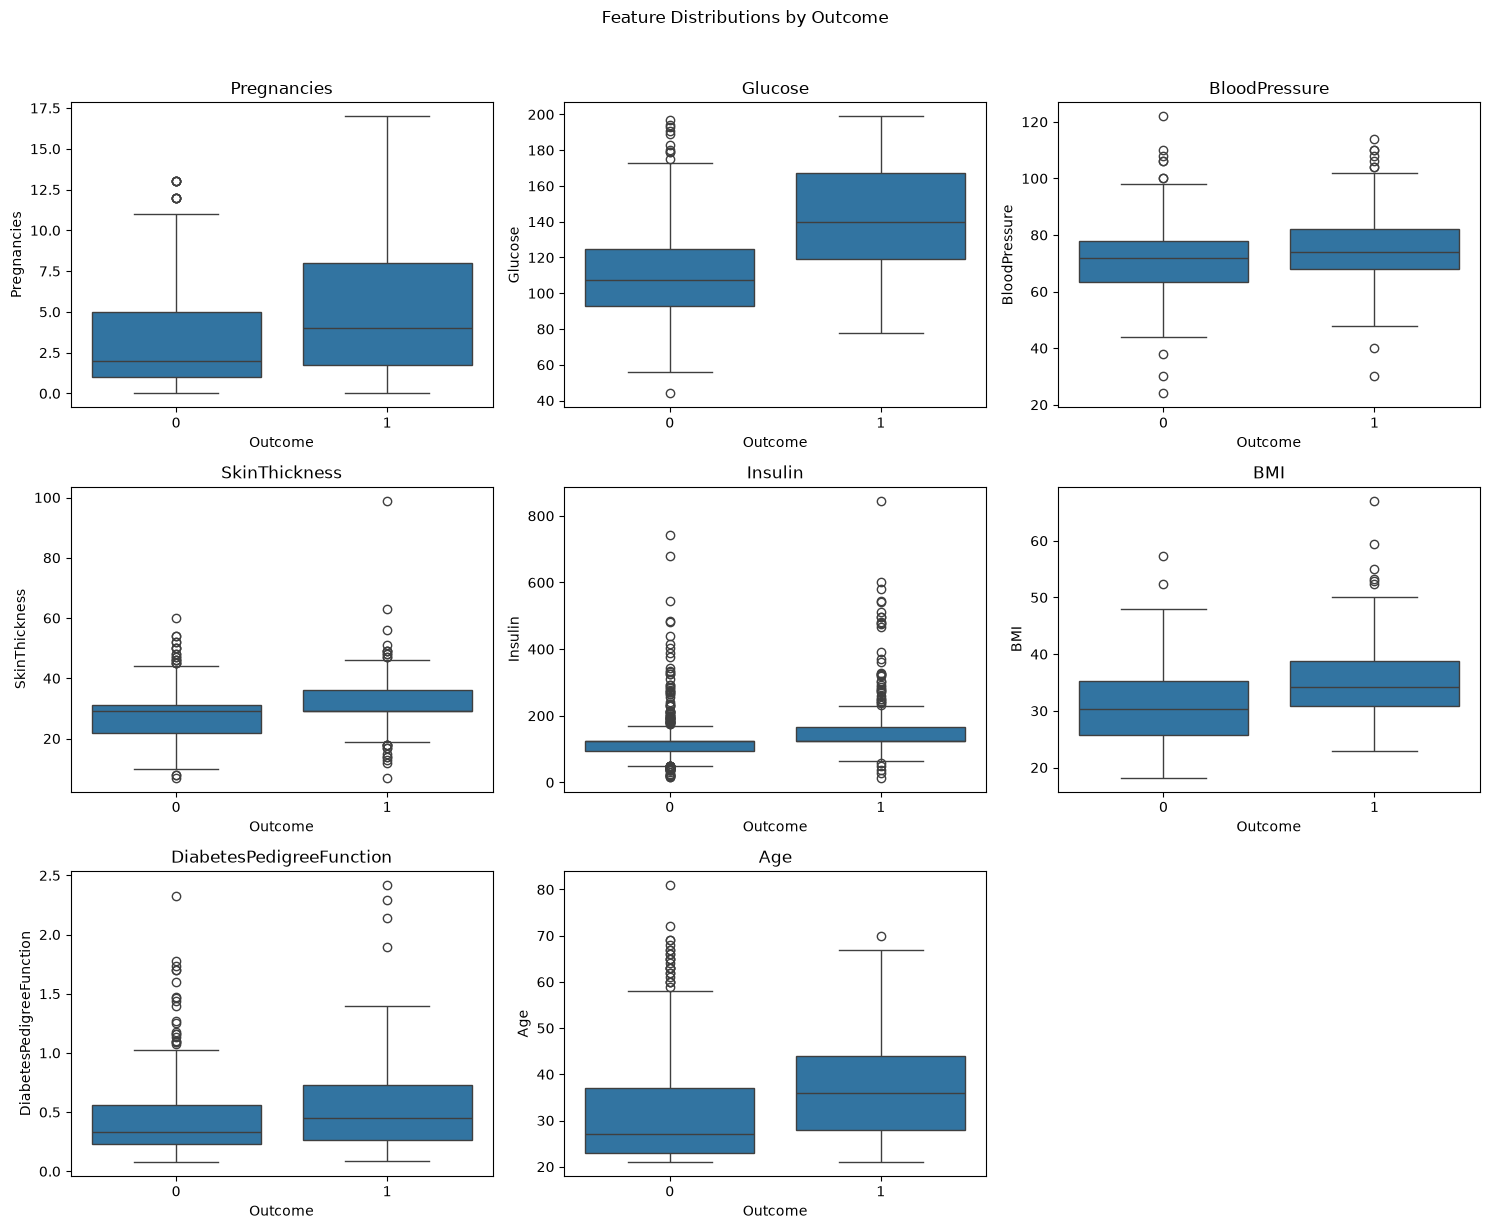

In [8]:
fig = plot_boxplots_by_outcome(df_clean, feature_cols, target_col, save_path="reports/figures/boxplots_for_features_by_outcome.png")

### Class-Separated Statistics  

Comparing the mean and median of each feature between non-diabetic (Outcome = 0) and diabetic (Outcome = 1) participants:  

| Feature | Mean (0) | Mean (1) | Median (0) | Median (1) |
|---|---:|---:|---:|---:|
| Pregnancies | 3.30 | 4.87 | 2 | 4 |
| Glucose | 110.68 | 142.13 | 107.5 | 140 |
| BloodPressure | 70.92 | 75.12 | 72 | 74 |
| SkinThickness | 27.73 | 31.69 | 29 | 29 |
| Insulin | 127.79 | 164.70 | 125 | 125 |
| BMI | 30.89 | 35.38 | 30.40 | 34.25 |
| DiabetesPedigreeFunction | 0.43 | 0.55 | 0.34 | 0.45 |
| Age | 31.19 | 37.07 | 27 | 36 |


**Observations:**

- Diabetic participants generally have higher **Glucose**, **BMI**, **Age**, **Insulin**, **SkinThickness**, and **DiabetesPedigreeFunction** values compared to non-diabetics.
- The differences are most pronounced for **Glucose** and **BMI**, aligning with their stronger correlation coefficients.
- Some features (e.g., **SkinThickness**, **Insulin**) show considerable spread and overlapping distributions, indicating that they contribute to risk but are not individually decisive.  

**Key Takeaway:**  
Features with the strongest correlation and class separation, particularly **Glucose** and **BMI**, will likely be the most influential in predictive modeling. Less correlated features can still add incremental predictive value when combined in a multivariate model.

## Next steps

With the data explored, `03_feature_engineering.ipynb` covers the train/test split and feature scaling that feed into modeling.